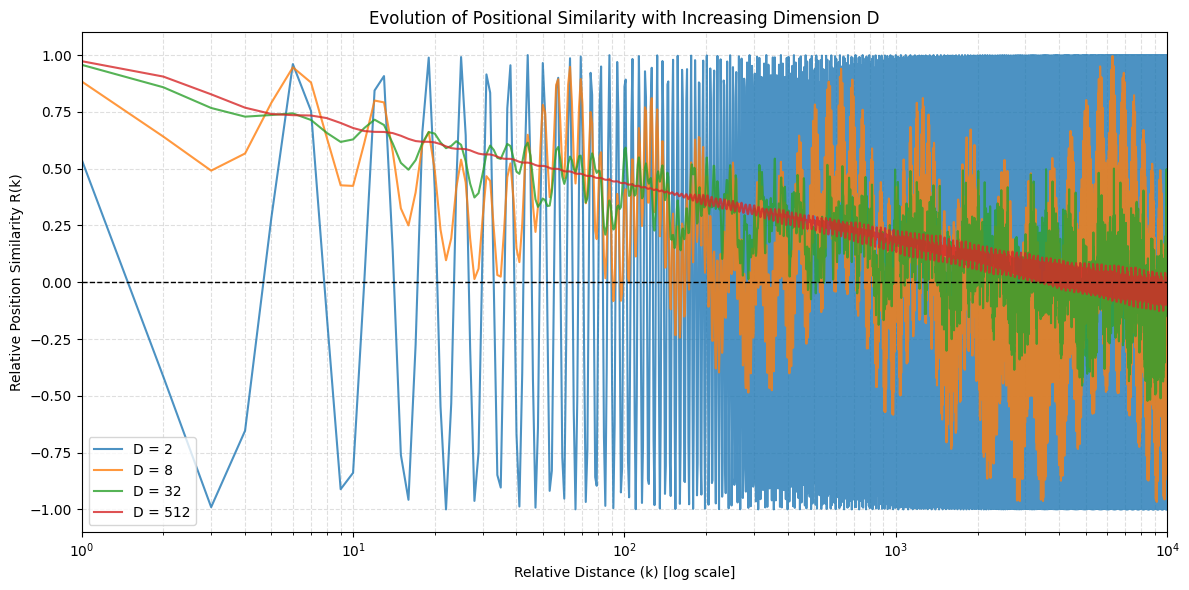

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_autocorrelation(k_vec, D_val, base_freq=10000):
    # D_val/2 is the number of frequency pairs
    i = np.arange(D_val // 2)
    omega = 1 / (base_freq ** (2 * i / D_val))
    # Outer product to get (k_vec.shape, omega.shape)
    cos_terms = np.cos(np.outer(k_vec, omega))
    return (2 / D_val) * np.sum(cos_terms, axis=1)

# Parameters
k = np.arange(0, 10001)
dimensions = [2, 8, 32, 128, 512] # Increasing D

plt.figure(figsize=(12, 6))

for D in dimensions:
    R = compute_autocorrelation(k, D)
    plt.plot(k, R, label=f'D = {D}', alpha=0.8)

# Formatting
plt.xscale('log')
plt.axhline(0, color='black', lw=1, ls='--')
plt.xlabel("Relative Distance (k) [log scale]")
plt.ylabel("Relative Position Similarity R(k)")
plt.title("Evolution of Positional Similarity with Increasing Dimension D")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.xlim(1, 10000)
plt.tight_layout()
plt.show()